**A. PENGUMPULAN DATA REVIEW MESJID 99 KUBAH MAKASSAR DI GOOGLE MAP**

In [17]:
import requests
import pandas as pd
import time

SERPAPI_API_KEY = "58a6d2bc76a88054e122b9836c80e7f54ebbd33998249f1382c32ad4859c5781"

DATA_ID = "0x2dbf1d4d6ad24f79:0x9f982d45f386a9fe"

BASE_PARAMS = {
    "api_key": SERPAPI_API_KEY,
    "engine": "google_maps_reviews",
    "data_id": DATA_ID,
    "hl": "id",
    "sort_by": "qualityScore"
}

response = requests.get("https://serpapi.com/search.json", params=BASE_PARAMS)
print(response.json())

{'search_metadata': {'id': '6965a2dc874d5073adb20a1d', 'status': 'Success', 'json_endpoint': 'https://serpapi.com/searches/396756697c16dcb1/6965a2dc874d5073adb20a1d.json', 'created_at': '2026-01-13 01:41:48 UTC', 'processed_at': '2026-01-13 01:41:48 UTC', 'google_maps_reviews_url': 'https://www.google.com/maps/place/data=!4m7!3m6!1s0x2dbf1d4d6ad24f79:0x9f982d45f386a9fe!5m2!4m1!1i2!9m1!1b1?hl=id&gl=', 'raw_html_file': 'https://serpapi.com/searches/396756697c16dcb1/6965a2dc874d5073adb20a1d.html', 'prettify_html_file': 'https://serpapi.com/searches/396756697c16dcb1/6965a2dc874d5073adb20a1d.prettify', 'total_time_taken': 1.25}, 'search_parameters': {'engine': 'google_maps_reviews', 'data_id': '0x2dbf1d4d6ad24f79:0x9f982d45f386a9fe', 'hl': 'id', 'sort_by': 'qualityScore'}, 'place_info': {'title': 'Masjid Kubah 99 Asmaul Husna', 'address': 'Jl. H. Bau No.36, Kunjung Mae, Kec. Mariso, Kota Makassar, Sulawesi Selatan 90125, Indonesia', 'rating': 4.7, 'reviews': 2279, 'type': 'Masjid'}, 'topics

In [18]:
MAX_REQUEST = 11
TARGET_REVIEW = 100

In [19]:
all_reviews = []
params = BASE_PARAMS.copy()

for i in range(MAX_REQUEST):
    print(f"Request ke-{i+1}")

    response = requests.get("https://serpapi.com/search", params=params)
    data = response.json()

    reviews = data.get("reviews", [])
    all_reviews.extend(reviews)

    print("Total review terkumpul:", len(all_reviews))

    if len(all_reviews) >= TARGET_REVIEW:
        print("Target review tercapai")
        break

    next_token = data.get("serpapi_pagination", {}).get("next_page_token")
    if not next_token:
        print("Tidak ada halaman lanjutan")
        break

    params["next_page_token"] = next_token

    time.sleep(2)

Request ke-1
Total review terkumpul: 8
Request ke-2
Total review terkumpul: 18
Request ke-3
Total review terkumpul: 28
Request ke-4
Total review terkumpul: 38
Request ke-5
Total review terkumpul: 48
Request ke-6
Total review terkumpul: 58
Request ke-7
Total review terkumpul: 68
Request ke-8
Total review terkumpul: 78
Request ke-9
Total review terkumpul: 88
Request ke-10
Total review terkumpul: 98
Request ke-11
Total review terkumpul: 108
Target review tercapai


In [23]:
rows = []

for r in all_reviews:
    rows.append({
        "nama_user": r.get("user", {}).get("name"),
        "rating": r.get("rating"),
        "tanggal": r.get("iso_date"),
        "ulasan": r.get("snippet")
    })

df = pd.DataFrame(rows)
df.head()

,nama_user,rating,tanggal,ulasan
0,Siba Waihi,5.0,2025-12-16T14:22:25Z,"Mesjid nya luas dan bersih, ada pengajian tema..."
1,Teguh Wahyudi,5.0,2025-12-05T07:16:52Z,"alhamdulillah bisa solat jumat, ornamen masjid..."
2,Muhammad Rasydin Sjatry Djafar,5.0,2025-09-12T15:52:27Z,Menjulang megah di kawasan reklamasi Center Po...
3,Faisal Reza Sukmawan,5.0,2025-08-12T13:30:39Z,Masjid yang megah dengan design unik dan menj...
4,Catur J. Sutrisno,3.0,2026-01-03T08:10:09Z,Masjid yang megah dengan design unik dan menj...


In [24]:
df.to_csv("review_mesjid_kubah_99.csv", index=False)

**B. PREPROCESSING DATA**

In [25]:
import pandas as pd

df = pd.read_csv("review_uad_kampus4.csv")
df.head()

,nama_user,rating,tanggal,ulasan
0,Siba Waihi,5.0,2025-12-16T14:22:25Z,"Mesjid nya luas dan bersih, ada pengajian tema..."
1,Teguh Wahyudi,5.0,2025-12-05T07:16:52Z,"alhamdulillah bisa solat jumat, ornamen masjid..."
2,Muhammad Rasydin Sjatry Djafar,5.0,2025-09-12T15:52:27Z,Menjulang megah di kawasan reklamasi Center Po...
3,Faisal Reza Sukmawan,5.0,2025-08-12T13:30:39Z,Masjid yang megah dengan design unik dan menj...
4,Catur J. Sutrisno,3.0,2026-01-03T08:10:09Z,Masjid yang megah dengan design unik dan menj...


In [26]:
import re

def cleaning_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["ulasan"].apply(cleaning_text)
df[["ulasan", "clean_text"]].head()

,ulasan,clean_text
0,"Mesjid nya luas dan bersih, ada pengajian tema...",mesjid nya luas dan bersih ada pengajian temat...
1,"alhamdulillah bisa solat jumat, ornamen masjid...",alhamdulillah bisa solat jumat ornamen masjid ...
2,Menjulang megah di kawasan reklamasi Center Po...,menjulang megah di kawasan reklamasi center po...
3,Masjid yang megah dengan design unik dan menj...,masjid yang megah dengan design unik dan menja...
4,Masjid yang megah dengan design unik dan menj...,masjid yang megah dengan design unik dan menja...


In [27]:
df["token"] = df["clean_text"].apply(lambda x: x.split())
df[["clean_text", "token"]].head()

,clean_text,token
0,mesjid nya luas dan bersih ada pengajian temat...,"[mesjid, nya, luas, dan, bersih, ada, pengajia..."
1,alhamdulillah bisa solat jumat ornamen masjid ...,"[alhamdulillah, bisa, solat, jumat, ornamen, m..."
2,menjulang megah di kawasan reklamasi center po...,"[menjulang, megah, di, kawasan, reklamasi, cen..."
3,masjid yang megah dengan design unik dan menja...,"[masjid, yang, megah, dengan, design, unik, da..."
4,masjid yang megah dengan design unik dan menja...,"[masjid, yang, megah, dengan, design, unik, da..."


In [28]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.4 MB/s eta 0:00:00


In [29]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

df["token_stopword"] = df["token"].apply(remove_stopwords)
df[["token", "token_stopword"]].head()

,token,token_stopword
0,"[mesjid, nya, luas, dan, bersih, ada, pengajia...","[mesjid, nya, luas, bersih, pengajian, tematik..."
1,"[alhamdulillah, bisa, solat, jumat, ornamen, m...","[alhamdulillah, solat, jumat, ornamen, masjid,..."
2,"[menjulang, megah, di, kawasan, reklamasi, cen...","[menjulang, megah, kawasan, reklamasi, center,..."
3,"[masjid, yang, megah, dengan, design, unik, da...","[masjid, megah, design, unik, menjadi, salah, ..."
4,"[masjid, yang, megah, dengan, design, unik, da...","[masjid, megah, design, unik, menjadi, salah, ..."


In [30]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer = StemmerFactory().create_stemmer()

def stemming_text(tokens):
    return [stemmer.stem(word) for word in tokens]

df["token_stem"] = df["token_stopword"].apply(stemming_text)
df[["token_stopword", "token_stem"]].head()

,token_stopword,token_stem
0,"[mesjid, nya, luas, bersih, pengajian, tematik...","[mesjid, nya, luas, bersih, aji, tematik, ruti..."
1,"[alhamdulillah, solat, jumat, ornamen, masjid,...","[alhamdulillah, solat, jumat, ornamen, masjid,..."
2,"[menjulang, megah, kawasan, reklamasi, center,...","[julang, megah, kawasan, reklamasi, center, po..."
3,"[masjid, megah, design, unik, menjadi, salah, ...","[masjid, megah, design, unik, jadi, salah, sat..."
4,"[masjid, megah, design, unik, menjadi, salah, ...","[masjid, megah, design, unik, jadi, salah, sat..."


In [31]:
df["final_text"] = df["token_stem"].apply(lambda x: " ".join(x))
df[["ulasan", "final_text"]].head()

,ulasan,final_text
0,"Mesjid nya luas dan bersih, ada pengajian tema...",mesjid nya luas bersih aji tematik rutin mingg...
1,"alhamdulillah bisa solat jumat, ornamen masjid...",alhamdulillah solat jumat ornamen masjid yg ar...
2,Menjulang megah di kawasan reklamasi Center Po...,julang megah kawasan reklamasi center point of...
3,Masjid yang megah dengan design unik dan menj...,masjid megah design unik jadi salah satu ikon ...
4,Masjid yang megah dengan design unik dan menj...,masjid megah design unik jadi salah satu ikon ...


In [34]:
df.to_csv("review_mesjid_kubah_99_preprocessed.csv", index=False)

**C. PELABELAN SENTIMEN LEXICON (positif / negatif / netral)**

In [35]:
import pandas as pd

df = pd.read_csv("review_mesjid_kubah_99_preprocessed.csv")
df[["ulasan", "final_text"]].head()

,ulasan,final_text
0,"Mesjid nya luas dan bersih, ada pengajian tema...",mesjid nya luas bersih aji tematik rutin mingg...
1,"alhamdulillah bisa solat jumat, ornamen masjid...",alhamdulillah solat jumat ornamen masjid yg ar...
2,Menjulang megah di kawasan reklamasi Center Po...,julang megah kawasan reklamasi center point of...
3,Masjid yang megah dengan design unik dan menj...,masjid megah design unik jadi salah satu ikon ...
4,Masjid yang megah dengan design unik dan menj...,masjid megah design unik jadi salah satu ikon ...


In [36]:
positive_words = set([
    "baik", "bagus", "bersih", "nyaman", "lengkap",
    "ramah", "murah", "cepat", "puas", "keren",
    "mantap", "modern", "teratur", "tenang", "islami", "rapi",
    "tertata", "luas", "nyaman", "sejuk", "luas",
    "rapi", "indah", "asri", "terawat", "khusyuk", "damai", "menenangkan",
    "lengkap", "ramah", "tertib", "megah", "strategis",
    "aman", "nyaring", "memadai", "wangi", "harum"
])

negative_words = set([
    "buruk", "jelek", "kotor", "mahal", "lambat",
    "kecewa", "panas", "ribet", "sempit", "bising",
    "rusak", "kurang", "susah",  "tidak nyaman", "bau", "gelap",
    "tidak terawat", "penuh", "kurang bersih", "macet",
    "terbatas", "tidak tertib", "kurang rapi", "buruk", "mengecewakan"
])

In [37]:
def sentiment_score(text):
    score = 0
    for word in text.split():
        if word in positive_words:
            score += 1
        elif word in negative_words:
            score -= 1
    return score

In [38]:
def sentiment_label(score):
    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    else:
        return "netral"

In [39]:
df["sentiment_score"] = df["final_text"].apply(sentiment_score)
df["sentiment"] = df["sentiment_score"].apply(sentiment_label)

df[["final_text", "sentiment_score", "sentiment"]].head()

,final_text,sentiment_score,sentiment
0,mesjid nya luas bersih aji tematik rutin mingg...,4,positif
1,alhamdulillah solat jumat ornamen masjid yg ar...,1,positif
2,julang megah kawasan reklamasi center point of...,7,positif
3,masjid megah design unik jadi salah satu ikon ...,3,positif
4,masjid megah design unik jadi salah satu ikon ...,1,positif


In [40]:
sentiment_count = df["sentiment"].value_counts()
sentiment_count

,count
sentiment,
positif,79
netral,25
negatif,4


In [42]:
df.to_csv("review_mesjid_kubah_99_sentiment.csv", index=False)

**D. VISUALISASI SENTIMEN POSITIF DAN NEGATIVE**

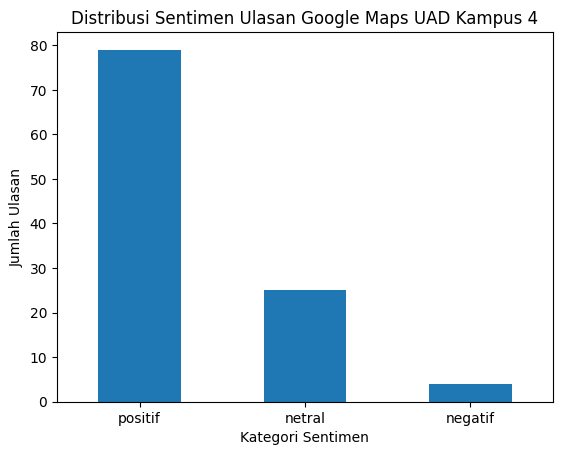

In [43]:
import matplotlib.pyplot as plt

plt.figure()
sentiment_count.plot(kind="bar")
plt.title("Distribusi Sentimen Ulasan Google Maps UAD Kampus 4")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=0)
plt.show()

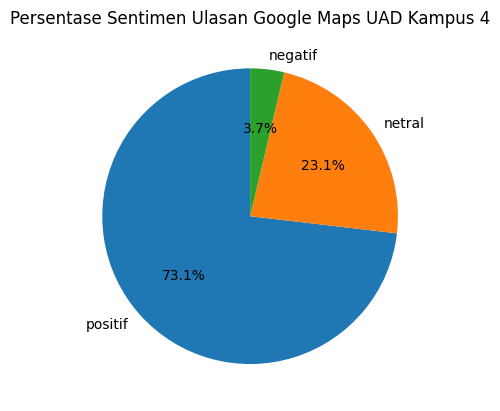

In [44]:
plt.figure()
sentiment_count.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Persentase Sentimen Ulasan Google Maps UAD Kampus 4")
plt.ylabel("")
plt.show()

**E. VISUALISASI WordCloud PER SENTIMEN**

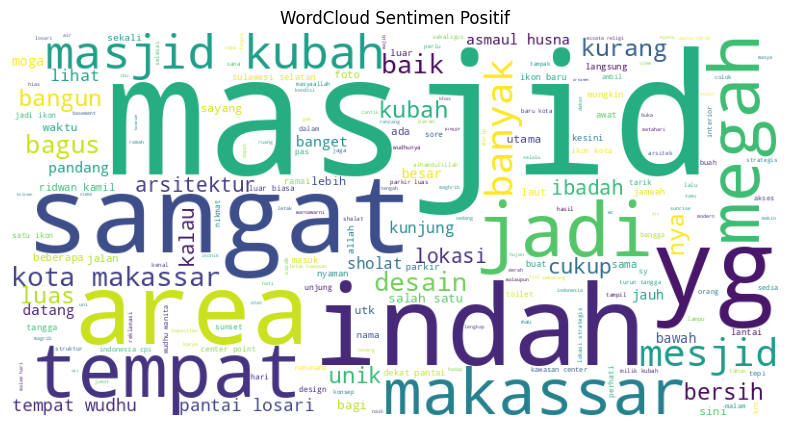

In [48]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

positive_text = " ".join(df[df['sentiment']=="positif"]['final_text'])

wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("WordCloud Sentimen Positif")
plt.show()


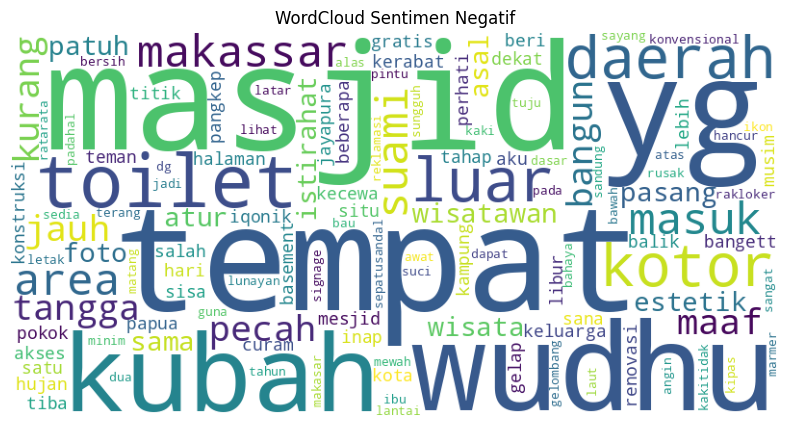

In [52]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

negative_text = " ".join(df[df['sentiment']=="negatif"]['final_text'])

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud Sentimen Negatif")
plt.show()


**F. PEMODELAN TOPIK**

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

tfidf = TfidfVectorizer(max_df=0.9, min_df=5)
tfidf_matrix = tfidf.fit_transform(df['final_text'])

lda = LatentDirichletAllocation(
    n_components=3,
    random_state=42
)
lda.fit(tfidf_matrix)

LatentDirichletAllocation(n_components=3, random_state=42)

In [56]:
feature_names = tfidf.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"\nTopik {idx+1}:")
    print(", ".join([feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]))


Topik 1:
ambil, tampil, tampak, warna, cerah, biasa, colok, namanama, jauh, sekali

Topik 2:
tempat, bagus, nya, wudhu, yg, kurang, masjid, sholat, bersih, tangga

Topik 3:
masjid, kubah, makassar, jadi, kota, losari, megah, pantai, indah, area
